In [ ]:
# 1. Install the connector
!pip install psycopg2-binary

# 2. Import the tools
import pandas as pd
import psycopg2

print("Step 1 Complete: Tools are ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 13.2 MB/s eta 0:00:00
Step 1 Complete: Tools are ready!


In [ ]:
from google.colab import files

# This will create a 'Choose Files' button
uploaded = files.upload()

Saving cannabis_sales.csv to cannabis_sales.csv


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('cannabis_sales.csv')
df['week_ending'] = pd.to_datetime(df['week_ending'])
df = df.sort_values('week_ending')
df['moving_avg_revenue'] = df['total_sales'].rolling(window=4).mean()
df['avg_price'] = df['total_sales'] / df['total_units']
df['price_pct_change'] = df['avg_price'].pct_change()
df['units_pct_change'] = df['total_units'].pct_change()
df['elasticity'] = df['units_pct_change'] / df['price_pct_change']
analysis_output = df[['week_ending', 'total_sales', 'moving_avg_revenue', 'avg_price', 'elasticity']].dropna().tail(10)
print("--- Market Dynamics Technical Summary ---")
print(f"Mean Price Elasticity: {df['elasticity'].mean():.2f}")
print("\nFinal Processed DataFrame (Ready for Power BI Export):")
print(analysis_output)

--- Market Dynamics Technical Summary ---
Mean Price Elasticity: 14.59

Final Processed DataFrame (Ready for Power BI Export):
   week_ending  total_sales  moving_avg_revenue  avg_price   elasticity
90  2024-06-15   5592848.89        4.123075e+06  37.889876     0.037955
91  2024-06-22   5727974.91        4.427738e+06  37.844886   -21.372851
92  2024-06-29   5654228.42        5.630918e+06  36.899789    -0.496858
93  2024-06-30    559233.52        4.383571e+06  36.692705   160.464774
94  2024-07-06   5313145.43        4.313646e+06  36.558676 -2336.751419
95  2024-07-13   5479768.70        4.251594e+06  36.912979     2.214464
96  2024-07-20   5440847.11        4.198249e+06  37.129257    -2.199372
97  2024-07-27   5516736.11        5.437624e+06  37.098525   -17.865893
98  2024-07-31   2902722.24        4.835019e+06  37.423576   -54.600828
99  2024-08-03   2858529.75        4.179709e+06  37.483016   -10.568613


In [ ]:
import pandas as pd

# 1. Load the data
df = pd.read_csv('cannabis_sales.csv')

# 2. Add the 4-week moving average
df['sales_moving_avg'] = df['total_sales'].rolling(window=4).mean()

# 3. FORCE Python to show every single column (no '...' truncation)
pd.set_option('display.max_columns', None)

# 4. Display the column names as a list
print("List of all columns:")
print(df.columns.tolist())

# 5. Show the first 5 rows of the entire table
df.head()

List of all columns:
['week_ending', 'adult_use_sales', 'medical_sales', 'total_sales', 'adult_units', 'medical_units', 'total_units', 'adult_avg_price', 'medical_avg_price', 'sales_moving_avg']


,week_ending,adult_use_sales,medical_sales,total_sales,adult_units,medical_units,total_units,adult_avg_price,medical_avg_price,sales_moving_avg
0,1/14/2023,1485019.32,1776700.69,3261720.01,33610,49312,82922,44.25,36.23,NaN
1,1/21/2023,1487815.81,2702525.61,4190341.42,33005,77461,110466,45.08,34.89,NaN
2,1/28/2023,1553216.30,2726237.56,4279453.86,34854,76450,111304,44.56,35.65,NaN
3,1/31/2023,578840.62,863287.86,1442128.48,12990,24023,37013,44.56,35.93,3.293411e+06
4,2/4/2023,1047436.20,1971731.40,3019167.60,24134,56666,80800,43.49,34.84,3.232773e+06


In [ ]:
# Fill the first 3 NaNs with the actual sales so the chart stays connected
df['sales_moving_avg'] = df['sales_moving_avg'].fillna(df['total_sales'])

# Export and Download
df.to_csv('final_cannabis_data_v2.csv', index=False)
from google.colab import files
files.download('final_cannabis_data_v2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# 1. Load the data
df = pd.read_csv('cannabis_sales.csv')

# 2. Add the 4-week moving average
df['sales_moving_avg'] = df['total_sales'].rolling(window=4).mean()

# 3. FORCE Python to show every single column (no '...' truncation)
pd.set_option('display.max_columns', None)

# 4. Display the column names as a list
print("List of all columns:")
print(df.columns.tolist())

# 5. Show the first 5 rows of the entire table
df.head()

List of all columns:
['week_ending', 'adult_use_sales', 'medical_sales', 'total_sales', 'adult_units', 'medical_units', 'total_units', 'adult_avg_price', 'medical_avg_price', 'sales_moving_avg']


,week_ending,adult_use_sales,medical_sales,total_sales,adult_units,medical_units,total_units,adult_avg_price,medical_avg_price,sales_moving_avg
0,1/14/2023,1485019.32,1776700.69,3261720.01,33610,49312,82922,44.25,36.23,NaN
1,1/21/2023,1487815.81,2702525.61,4190341.42,33005,77461,110466,45.08,34.89,NaN
2,1/28/2023,1553216.30,2726237.56,4279453.86,34854,76450,111304,44.56,35.65,NaN
3,1/31/2023,578840.62,863287.86,1442128.48,12990,24023,37013,44.56,35.93,3.293411e+06
4,2/4/2023,1047436.20,1971731.40,3019167.60,24134,56666,80800,43.49,34.84,3.232773e+06


In [ ]:
# Fill the first 3 NaNs with the actual sales to keep the line chart continuous
df['sales_moving_avg'] = df['sales_moving_avg'].fillna(df['total_sales'])

# Export the clean file
df.to_csv('final_cannabis_data_v2.csv', index=False)

# Download it to your computer
from google.colab import files
files.download('final_cannabis_data_v2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Exporting the final dataset with the moving average included
df.to_csv('final_cannabis_data_v2.csv', index=False)

# Triggering the download to your local machine
files.download('final_cannabis_data_v2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

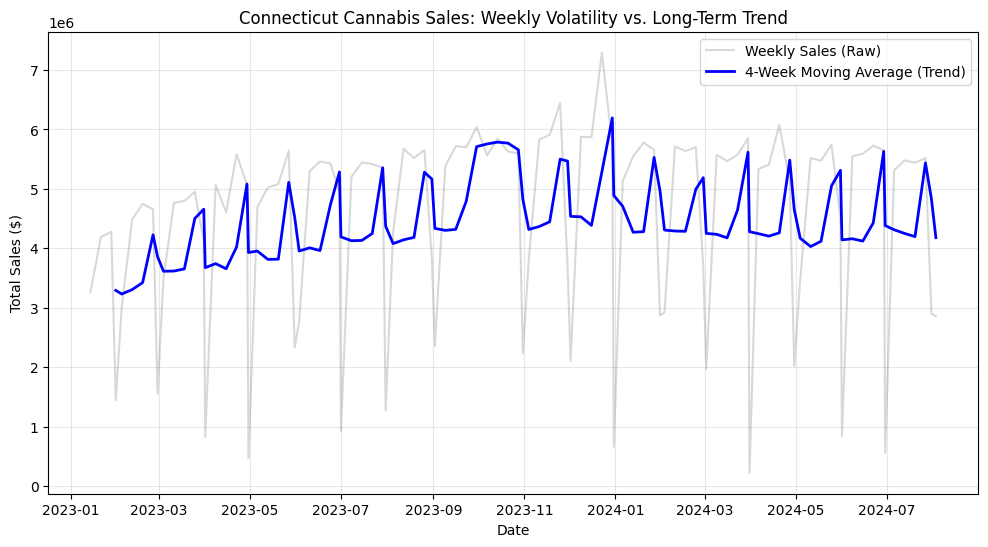

In [ ]:
# Create a 4-week moving average to smooth out the 'noise'
df['sales_moving_avg'] = df['total_sales'].rolling(window=4).mean()

# Plot the raw sales vs the smooth moving average
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['total_sales'], label='Weekly Sales (Raw)', alpha=0.3, color='gray')
plt.plot(df.index, df['sales_moving_avg'], label='4-Week Moving Average (Trend)', color='blue', linewidth=2)

plt.title('Connecticut Cannabis Sales: Weekly Volatility vs. Long-Term Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

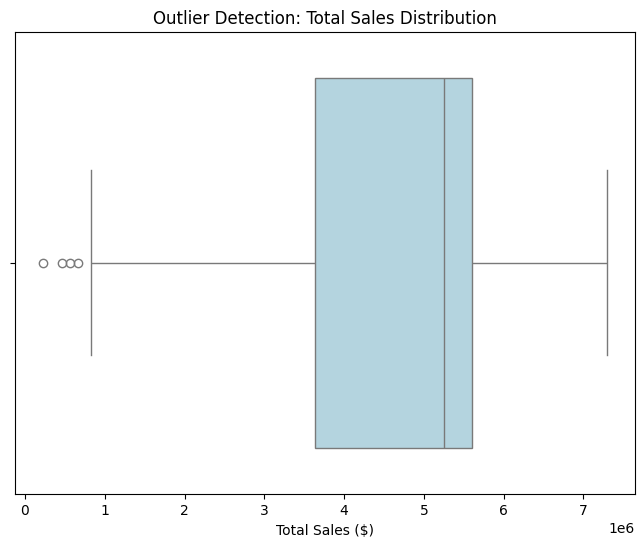

Step 4 Complete: Look for any dots outside the 'whiskers' of the box.


In [ ]:
# Create a Box Plot to see if there are any 'crazy' numbers in our sales data
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['total_sales'], color='lightblue')

plt.title('Outlier Detection: Total Sales Distribution')
plt.xlabel('Total Sales ($)')
plt.show()

print("Step 4 Complete: Look for any dots outside the 'whiskers' of the box.")

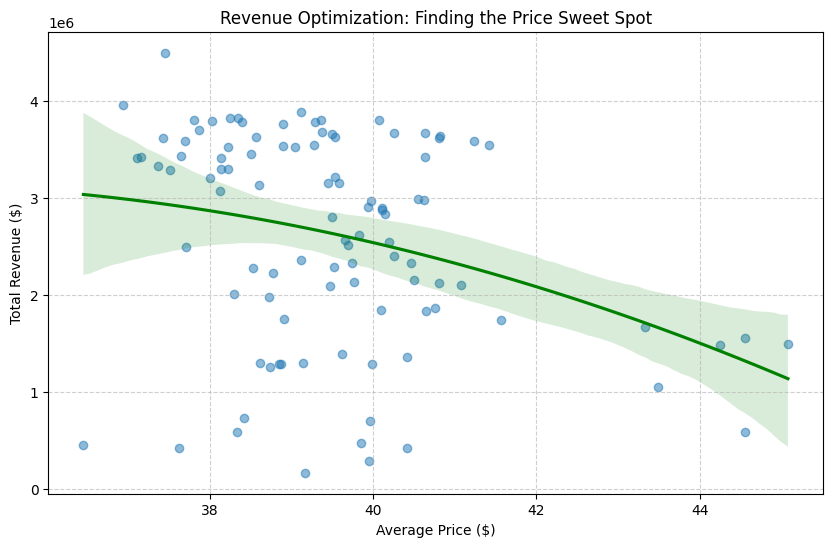

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot to find the 'Sweet Spot'
plt.figure(figsize=(10, 6))
sns.regplot(x='adult_avg_price', y='adult_use_sales', data=df,
            order=2, # This 'order=2' creates a curved line to find the peak
            scatter_kws={'alpha':0.5}, line_kws={'color':'green'})

plt.title('Revenue Optimization: Finding the Price Sweet Spot')
plt.xlabel('Average Price ($)')
plt.ylabel('Total Revenue ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Medical Price Sensitivity: 0.04
Adult-Use Price Sensitivity: -0.38


/tmp/ipykernel_6839/2367963783.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segments, y=correlations, palette='viridis')


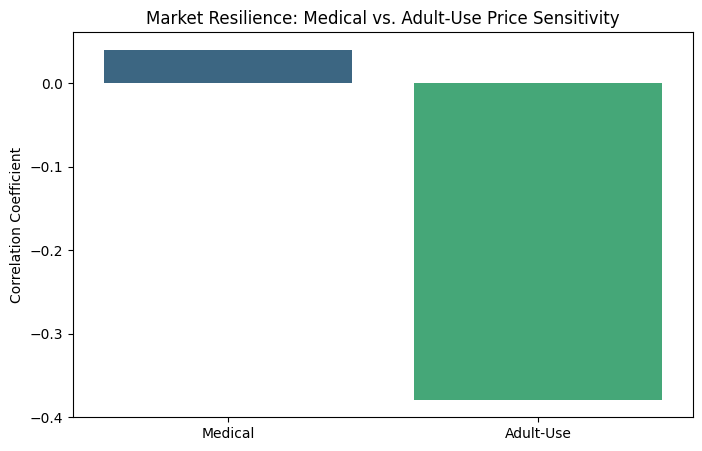

In [ ]:
# Compare the correlation of Price vs Units for both segments
medical_corr = df['medical_avg_price'].corr(df['medical_units'])
adult_corr = df['adult_avg_price'].corr(df['adult_units'])

print(f"Medical Price Sensitivity: {medical_corr:.2f}")
print(f"Adult-Use Price Sensitivity: {adult_corr:.2f}")

# Visualizing the difference
segments = ['Medical', 'Adult-Use']
correlations = [medical_corr, adult_corr]

plt.figure(figsize=(8, 5))
sns.barplot(x=segments, y=correlations, palette='viridis')
plt.title('Market Resilience: Medical vs. Adult-Use Price Sensitivity')
plt.ylabel('Correlation Coefficient')
plt.show()

In [ ]:
from google.colab import files
files.download("cannabis_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>